In [1]:
import pandas as pd
import numpy as np
import pandas_datareader.data as web
import yfinance as yf
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import warnings
import torch
import timesfm
from datetime import timedelta
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

# ==========================================
# 第一部分：資料準備與變數定義
# ==========================================

print(">>> [Step 1] 正在初始化資料與環境...")

# 1. 參數設定
TARGET_COL = 'Target_DGS2'
TEST_START_DATE = '2019-01-01' 
LOOKBACK_WINDOW = 24
CORR_THRESHOLD = 0.7
CONTEXT_LEN = 512
TRADING_DAYS_PER_MONTH = 21

# 2. 變數分類
CONTINUOUS_VARS = [
    'Yield_10Y', 'Yield_Spread_10Y2Y', 'Fed_Funds', 'Inflation_Exp', 'Financial_Cond',
    'Oil_WTI', 'Copper', 'Dollar_Index', 'S&P500', 'Copper_Oil_Ratio', 'Fed_Assets'
]

SHOCK_VARS = [
    'Core_PCE', 'PCE_Price', 'CPI', 'Core_CPI', 'PPI',
    'Unemployment', 'Nonfarm_Payrolls', 'Hourly_Earnings', 'Jobless_Claims', 'JOLTS_Openings', 'Labor_Partic',
    'Real_GDP', 'Ind_Production', 'Retail_Sales', 'Debt_to_GDP',
    'Mich_Sentiment', 'FOMC_Sentiment'
]

MACRO_INDICATORS = {
    'Core_PCE': {'ticker': 'PCEPILFE', 'source': 'fred'},
    'PCE_Price': {'ticker': 'PCEPI', 'source': 'fred'},
    'CPI': {'ticker': 'CPIAUCSL', 'source': 'fred'},
    'Core_CPI': {'ticker': 'CPILFESL', 'source': 'fred'},
    'PPI': {'ticker': 'PPIACO', 'source': 'fred'},
    'Inflation_Exp': {'ticker': 'T10YIE', 'source': 'fred'},
    'Unemployment': {'ticker': 'UNRATE', 'source': 'fred'},
    'Nonfarm_Payrolls': {'ticker': 'PAYEMS', 'source': 'fred'},
    'Hourly_Earnings': {'ticker': 'CES0500000003', 'source': 'fred'},
    'Jobless_Claims': {'ticker': 'ICSA', 'source': 'fred'},
    'JOLTS_Openings': {'ticker': 'JTSJOL', 'source': 'fred'},
    'Labor_Partic': {'ticker': 'CIVPART', 'source': 'fred'},
    'Real_GDP': {'ticker': 'GDPC1', 'source': 'fred'},
    'Ind_Production': {'ticker': 'INDPRO', 'source': 'fred'},
    'Retail_Sales': {'ticker': 'RSAFS', 'source': 'fred'},
    'Debt_to_GDP': {'ticker': 'GFDEGDQ188S', 'source': 'fred'},
    'Mich_Sentiment': {'ticker': 'UMCSENT', 'source': 'fred'},
    'Financial_Cond': {'ticker': 'NFCI', 'source': 'fred'},
    'Yield_10Y': {'ticker': 'DGS10', 'source': 'fred'},
    'Yield_Spread_10Y2Y': {'ticker': 'T10Y2Y', 'source': 'fred'},
    'Fed_Funds': {'ticker': 'DFF', 'source': 'fred'},
    'Fed_Assets': {'ticker': 'WALCL', 'source': 'fred'},
    'Oil_WTI': {'ticker': 'CL=F', 'source': 'yahoo'},
    'Copper': {'ticker': 'HG=F', 'source': 'yahoo'},
    'Dollar_Index': {'ticker': 'DX-Y.NYB', 'source': 'yahoo'},
    'S&P500': {'ticker': '^GSPC', 'source': 'yahoo'},
}

EVENT_DATES_MAP = {}

def fetch_and_process_data(start_date='2015-01-01'):
    global EVENT_DATES_MAP
    try:
        target = web.DataReader('DGS2', 'fred', start=start_date)
        target.columns = [TARGET_COL]
        full_idx = pd.date_range(start=target.index.min(), end=target.index.max(), freq='D')
        df_pool = target.reindex(full_idx).ffill()
    except: return pd.DataFrame()

    for name, info in tqdm(MACRO_INDICATORS.items(), desc="Fetching Data"):
        try:
            if info['source'] == 'fred':
                s = web.DataReader(info['ticker'], 'fred', start=start_date).iloc[:, 0]
            elif info['source'] == 'yahoo':
                d = yf.download(info['ticker'], start=start_date, progress=False)
                s = d['Adj Close'] if 'Adj Close' in d.columns else d['Close']
            if isinstance(s, pd.DataFrame): s = s.iloc[:, 0]
            valid_dates = set(s.dropna().index.normalize().tolist())
            EVENT_DATES_MAP[name] = valid_dates
            df_pool[name] = s.reindex(df_pool.index).ffill()
        except Exception: continue
            
    fomc_file = r"data\processed\FOMC_Analysis_Rigorous_TimeSeries.csv"
    if os.path.exists(fomc_file):
        try:
            df_fomc = pd.read_csv(fomc_file)
            df_fomc['Date'] = pd.to_datetime(df_fomc['Date'])
            fomc_dates = set(df_fomc['Date'].dt.normalize().tolist())
            EVENT_DATES_MAP['FOMC_Sentiment'] = fomc_dates
            df_fomc = df_fomc.set_index('Date').sort_index()
            if 'Score' in df_fomc.columns:
                df_pool['FOMC_Sentiment'] = df_fomc['Score'].reindex(df_pool.index).ffill()
                print(f"    📅 FOMC 數據已載入")
        except: pass

    if 'Copper' in df_pool.columns and 'Oil_WTI' in df_pool.columns:
        df_pool['Copper_Oil_Ratio'] = df_pool['Copper'] / df_pool['Oil_WTI']
        if 'Copper' in EVENT_DATES_MAP and 'Oil_WTI' in EVENT_DATES_MAP:
            EVENT_DATES_MAP['Copper_Oil_Ratio'] = EVENT_DATES_MAP['Copper'].union(EVENT_DATES_MAP['Oil_WTI'])

    downloaded_vars = set(df_pool.columns) - {TARGET_COL}
    classified_vars = set(CONTINUOUS_VARS) | set(SHOCK_VARS)
    missing_vars = downloaded_vars - classified_vars
    if missing_vars: CONTINUOUS_VARS.extend(list(missing_vars))

    return df_pool.dropna()

data_pool = fetch_and_process_data(start_date='2015-01-01')
print(f"✅ 資料準備完成，總筆數: {len(data_pool)}")

D:\Anaconda\Anaconda3\envs\llm_2025\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


>>> [Step 1] 正在初始化資料與環境...


Fetching Data: 100%|██████████| 26/26 [00:43<00:00,  1.68s/it]

    📅 FOMC 數據已載入
✅ 資料準備完成，總筆數: 3933


In [2]:
# ==========================================
# 第二部分：多模式混合模型邏輯
# ==========================================

class SmartDecayGenerator:
    @staticmethod
    def generate_future_path(last_val, steps, col_name, continuous_vars):
        t = np.arange(steps)
        if col_name in continuous_vars: return np.full(steps, last_val)
        else: return last_val * 0.5 * (1 + np.cos(t * np.pi / steps))

    @staticmethod
    def generate_sawtooth_history(series, date_map, col_name, continuous_vars):
        arr = series.values; dates = series.index; n = len(arr)
        if col_name in continuous_vars: return series
        decayed_arr = np.zeros(n); last_reset_val = arr[0]; steps_since_reset = 0; decay_span = 45
        event_dates = date_map.get(col_name, set())
        for i in range(n):
            is_reset = (i == 0) or (dates[i] in event_dates) or (arr[i] != arr[i-1])
            if is_reset: last_reset_val = arr[i]; steps_since_reset = 0; decayed_arr[i] = last_reset_val
            else:
                steps_since_reset += 1; t = min(steps_since_reset, decay_span)
                decayed_arr[i] = last_reset_val * 0.5 * (1 + np.cos(t * np.pi / decay_span))
        return pd.Series(decayed_arr, index=dates)

def get_high_corr_features(df, target_col, cutoff_date, threshold=0.7):
    valid_data = df.loc[:cutoff_date].iloc[-(LOOKBACK_WINDOW*30):].copy()
    monthly_data = valid_data.resample('ME').last() 
    if monthly_data.empty: monthly_data = valid_data.resample('M').last()
    monthly_diff = monthly_data.diff()
    selected = []
    target_series = monthly_diff[target_col]
    for col in df.columns:
        if col == target_col: continue
        if col in monthly_diff.columns:
            feat_series = monthly_diff[col].shift(1)
            temp_df = pd.concat([target_series, feat_series], axis=1).dropna()
            if len(temp_df) > 10 and temp_df[col].std() != 0:
                corr = temp_df[target_col].corr(temp_df[col])
                if not np.isnan(corr) and abs(corr) >= threshold: selected.append(col)
    return selected

def predict_hybrid(history_df, horizon_days, target_col, date_map, continuous_vars, device, mode='all'):
    """
    mode 選項:
    1. 'univariate': 僅 DGS2 (純 TimesFM)
    2. 'macro_only': DGS2 + Marco Indicators
    3. 'fomc_only': DGS2 + FOMC
    4. 'all': DGS2 + FOMC + Macro Indicators
    """
    cutoff_date = history_df.index[-1]
    
    # --- A. TimesFM Baseline (所有模式共用) ---
    context_y = history_df[target_col].values.astype(np.float32)
    if len(context_y) >= CONTEXT_LEN: ctx = context_y[-CONTEXT_LEN:]
    else:
        padding = np.zeros(CONTEXT_LEN - len(context_y), dtype=np.float32)
        ctx = np.concatenate([padding, context_y])
        
    tfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained("google/timesfm-2.5-200m-pytorch", device=device)
    config = timesfm.ForecastConfig(max_context=CONTEXT_LEN, max_horizon=horizon_days, normalize_inputs=True)
    tfm.compile(config)
    
    baseline_pred_raw = tfm.forecast(inputs=[ctx], horizon=horizon_days)
    if isinstance(baseline_pred_raw, tuple): baseline_pred_raw = baseline_pred_raw[0]
    if isinstance(baseline_pred_raw, torch.Tensor): baseline_pred_raw = baseline_pred_raw.cpu().numpy()
    if isinstance(baseline_pred_raw, list): baseline_pred_raw = np.array(baseline_pred_raw)
    if baseline_pred_raw.ndim == 3: baseline_pred_raw = baseline_pred_raw[:, 0, :]
    baseline_pred = baseline_pred_raw[0]

    # 若是單變數模式，直接回傳 Baseline
    if mode == 'univariate':
        return baseline_pred

    # --- B. Ridge Correction (根據 mode 選擇特徵) ---
    train_start = cutoff_date - timedelta(days=730)
    train_mask = (history_df.index >= train_start) & (history_df.index <= cutoff_date)
    y_train = history_df.loc[train_mask, target_col].values
    
    if len(y_train) < 100: return baseline_pred

    # 1. 取得高相關特徵
    high_corr_feats = get_high_corr_features(history_df, target_col, cutoff_date, threshold=CORR_THRESHOLD)
    
    # 2. 根據 Mode 過濾特徵
    final_feats = []
    
    if mode == 'macro_only':
        # 排除 FOMC，只留 Macro
        final_feats = [f for f in high_corr_feats if f != 'FOMC_Sentiment']
        
    elif mode == 'fomc_only':
        # 只留 FOMC (若存在)
        if 'FOMC_Sentiment' in history_df.columns:
            final_feats = ['FOMC_Sentiment']
            
    elif mode == 'all':
        # Macro + FOMC
        macro = [f for f in high_corr_feats if f != 'FOMC_Sentiment']
        fomc = ['FOMC_Sentiment'] if 'FOMC_Sentiment' in history_df.columns else []
        final_feats = macro + fomc
        
    if not final_feats: return baseline_pred

    try:
        ridge = Ridge(alpha=1.0)
        scaler = StandardScaler()
        X_train_list = []; X_fut_list = []; curr_feats_list = []
        
        for f in final_feats:
            hist_saw = SmartDecayGenerator.generate_sawtooth_history(
                history_df.loc[train_mask, f], date_map, f, continuous_vars
            ).values
            X_train_list.append(hist_saw)
            
            last_v = history_df[f].iloc[-1]
            curr_feats_list.append(last_v)
            fut_path = SmartDecayGenerator.generate_future_path(last_v, horizon_days, f, continuous_vars)
            X_fut_list.append(fut_path)
            
        X_train = np.stack(X_train_list, axis=1)
        X_fut = np.stack(X_fut_list, axis=1)
        
        scaler.fit(X_train)
        ridge.fit(scaler.transform(X_train), y_train)
        
        curr_bias = ridge.predict(scaler.transform(np.array([curr_feats_list])))[0]
        fut_bias = ridge.predict(scaler.transform(X_fut))
        
        final_pred = baseline_pred + (fut_bias - curr_bias) * 0.5
        return final_pred
        
    except:
        return baseline_pred

In [3]:
# ==========================================
# 第三部分：4組策略對比回測
# ==========================================

def run_comparative_backtest(df, target_col, date_map, continuous_vars):
    print("\n>>> [Step 2] 啟動多策略對比回測 (4 Scenarios)...")
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"    運算裝置: {device.upper()}")

    # 設定回測時間軸
    latest_date = df.index[-1]
    start_test_date = pd.Timestamp('2019-01-01')
    end_test_limit = latest_date - pd.DateOffset(months=6)
    
    test_cutoff_dates = []
    current_cutoff = start_test_date
    while current_cutoff <= end_test_limit:
        test_cutoff_dates.append(current_cutoff)
        current_cutoff += pd.DateOffset(months=1)
    
    print(f"    測試基準點數量: {len(test_cutoff_dates)}")
    
    # 定義 4 種策略模式
    scenarios = {
        '1. DGS2 Only': 'univariate',
        '2. DGS2 + Macro': 'macro_only',
        '3. DGS2 + FOMC': 'fomc_only',
        '4. All Combined': 'all'
    }
    
    # 儲存結果: comparison_results[scenario][month] = [mape_list]
    comparison_results = {s_name: {m: [] for m in range(1, 7)} for s_name in scenarios}
    
    # 開始回測
    for idx, cutoff in enumerate(test_cutoff_dates):
        print(f"    [{idx+1}/{len(test_cutoff_dates)}] 基準日: {cutoff.date()} | ", end="")
        history_data = df[df.index <= cutoff].copy()
        
        # 對每種策略分別執行預測
        for s_name, mode in scenarios.items():
            print(f".", end="") # 進度點
            
            for m in range(1, 7):
                horizon_days = m * TRADING_DAYS_PER_MONTH
                future_truth = df[df.index > cutoff].head(horizon_days)
                actuals = future_truth[target_col].values
                
                if len(actuals) < horizon_days: continue
                
                # 呼叫預測 (帶入 mode)
                preds = predict_hybrid(history_data, horizon_days, target_col, date_map, continuous_vars, device, mode=mode)
                mape = np.mean(np.abs((actuals - preds) / actuals)) * 100
                comparison_results[s_name][m].append(mape)
        print("") # 換行

    # --- 統整與視覺化 ---
    print("\n" + "="*60)
    print(f"{'策略組合':<20} | {'1M':<8} {'2M':<8} {'3M':<8} {'4M':<8} {'5M':<8} {'6M':<8} | {'Avg':<8}")
    print("="*60)
    
    final_scores = {} # 記錄每個策略的總平均 MAPE

    plot_data = {s: [] for s in scenarios}
    
    for s_name in scenarios:
        row_str = f"{s_name:<20} | "
        total_mape = 0
        count = 0
        for m in range(1, 7):
            val = np.mean(comparison_results[s_name][m]) if comparison_results[s_name][m] else 0
            plot_data[s_name].append(val)
            row_str += f"{val:6.2f}%  "
            total_mape += val
            count += 1
        
        avg_score = total_mape / count if count > 0 else 0
        final_scores[s_name] = avg_score
        print(f"{row_str}| {avg_score:6.2f}%")
            
    print("="*60)

    # 繪圖：分組長條圖
    x = np.arange(1, 7)
    width = 0.2
    plt.figure(figsize=(12, 6))
    
    offsets = [-1.5, -0.5, 0.5, 1.5]
    colors = ['gray', 'orange', 'green', 'red']
    
    for i, (s_name, vals) in enumerate(plot_data.items()):
        plt.bar(x + offsets[i]*width, vals, width, label=s_name, color=colors[i], alpha=0.8)

    plt.title('Performance Comparison: MAPE by Scenario & Horizon')
    plt.xlabel('Forecast Horizon (Months)')
    plt.ylabel('MAPE (%)')
    plt.xticks(x, [f'{m}M' for m in x])
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.show()

    # 選出最佳策略
    best_scenario = min(final_scores, key=final_scores.get)
    best_mode = scenarios[best_scenario]
    print(f"\n🏆 最佳策略: [{best_scenario}] (Avg MAPE: {final_scores[best_scenario]:.2f}%)")
    
    return best_mode, best_scenario


>>> [Step 2] 啟動多策略對比回測 (4 Scenarios)...
    運算裝置: CUDA
    測試基準點數量: 78
    [1/78] 基準日: 2019-01-01 | .Downloaded.
Downloaded.
Downloaded.
Downloaded.
Downloaded.
Downloaded.
.Downloaded.
Downloaded.
Downloaded.
Downloaded.
Downloaded.
Downloaded.
.Downloaded.
Downloaded.
Downloaded.
Downloaded.
Downloaded.
Downloaded.
.Downloaded.
Downloaded.
Downloaded.
Downloaded.
Downloaded.
Downloaded.

    [2/78] 基準日: 2019-02-01 | .Downloaded.
Downloaded.
Downloaded.
Downloaded.
Downloaded.
Downloaded.
.Downloaded.
Downloaded.
Downloaded.
Downloaded.
Downloaded.
Downloaded.
.Downloaded.
Downloaded.
Downloaded.
Downloaded.
Downloaded.
Downloaded.
.Downloaded.
Downloaded.
Downloaded.
Downloaded.
Downloaded.
Downloaded.

    [3/78] 基準日: 2019-03-01 | .Downloaded.
Downloaded.
Downloaded.
Downloaded.
Downloaded.
Downloaded.
.Downloaded.
Downloaded.
Downloaded.
Downloaded.
Downloaded.
Downloaded.
.Downloaded.
Downloaded.
Downloaded.
Downloaded.
Downloaded.
Downloaded.
.Downloaded.
Downloaded.
Downloaded.

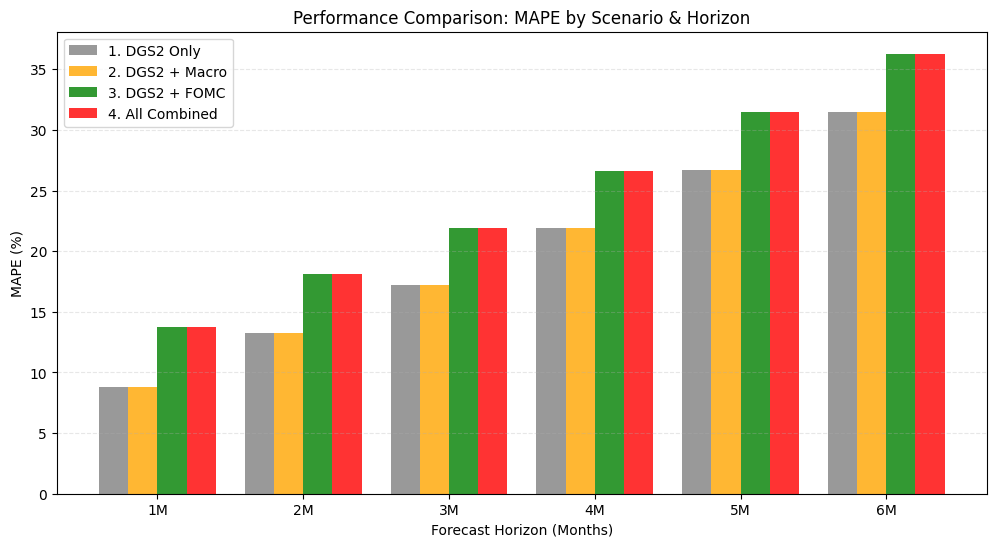


🏆 最佳策略: [1. DGS2 Only] (Avg MAPE: 19.88%)

>>> [Step 3] 執行最終預測
    使用策略: 1. DGS2 Only
    預測區間: 未來 6 個月
Downloaded.


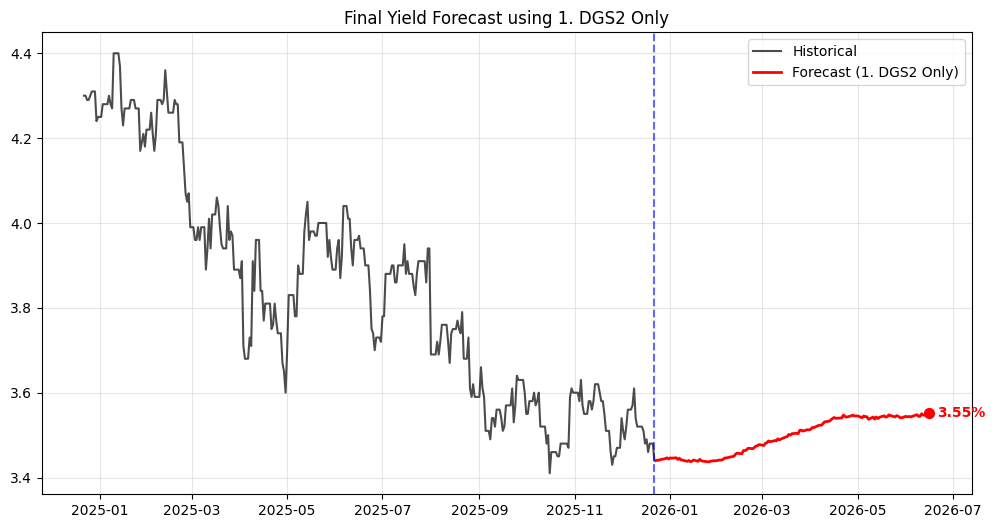

最終預測結果 (1. DGS2 Only): 3.5520%


In [4]:
# ==========================================
# 第四部分：執行最佳策略的未來預測
# ==========================================

if __name__ == "__main__":
    if 'data_pool' in locals():
        # 1. 執行對比回測並取得最佳模式
        best_mode, best_scenario_name = run_comparative_backtest(data_pool, TARGET_COL, EVENT_DATES_MAP, CONTINUOUS_VARS)
        
        # 2. 執行未來預測
        FUTURE_MONTHS = 6
        FUTURE_HORIZON = FUTURE_MONTHS * 21
        device = "cuda" if torch.cuda.is_available() else "cpu"
        latest_date = data_pool.index[-1]

        print(f"\n>>> [Step 3] 執行最終預測")
        print(f"    使用策略: {best_scenario_name}")
        print(f"    預測區間: 未來 {FUTURE_MONTHS} 個月")

        future_values = predict_hybrid(
            data_pool, 
            FUTURE_HORIZON, 
            TARGET_COL, 
            EVENT_DATES_MAP, 
            CONTINUOUS_VARS, 
            device,
            mode=best_mode # ★ 關鍵：使用最佳模式
        )

        # 建立時間軸與繪圖
        future_dates = pd.bdate_range(start=latest_date + pd.Timedelta(days=1), periods=FUTURE_HORIZON)
        df_forecast = pd.Series(future_values, index=future_dates, name='Forecast_Yield')

        plt.figure(figsize=(12, 6))
        plot_history_start = latest_date - pd.DateOffset(months=12)
        history_segment = data_pool.loc[plot_history_start:, TARGET_COL]

        plt.plot(history_segment.index, history_segment.values, label='Historical', color='black', alpha=0.7)
        plt.plot(df_forecast.index, df_forecast.values, label=f'Forecast ({best_scenario_name})', color='red', linewidth=2)
        plt.axvline(x=latest_date, color='blue', linestyle='--', alpha=0.6)
        
        final_val = df_forecast.iloc[-1]
        plt.scatter([df_forecast.index[-1]], [final_val], color='red', s=50, zorder=5)
        plt.text(df_forecast.index[-1] + pd.Timedelta(days=5), final_val, f"{final_val:.2f}%", 
                 fontsize=10, fontweight='bold', color='red', va='center')

        plt.title(f"Final Yield Forecast using {best_scenario_name}")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        
        print(f"最終預測結果 ({best_scenario_name}): {final_val:.4f}%")

>>> [最終預測] 啟動策略 4 (All Combined)
    數據截止日: 2025-12-22
    預測區間: 未來 6 個月
    使用模式: all
Downloaded.


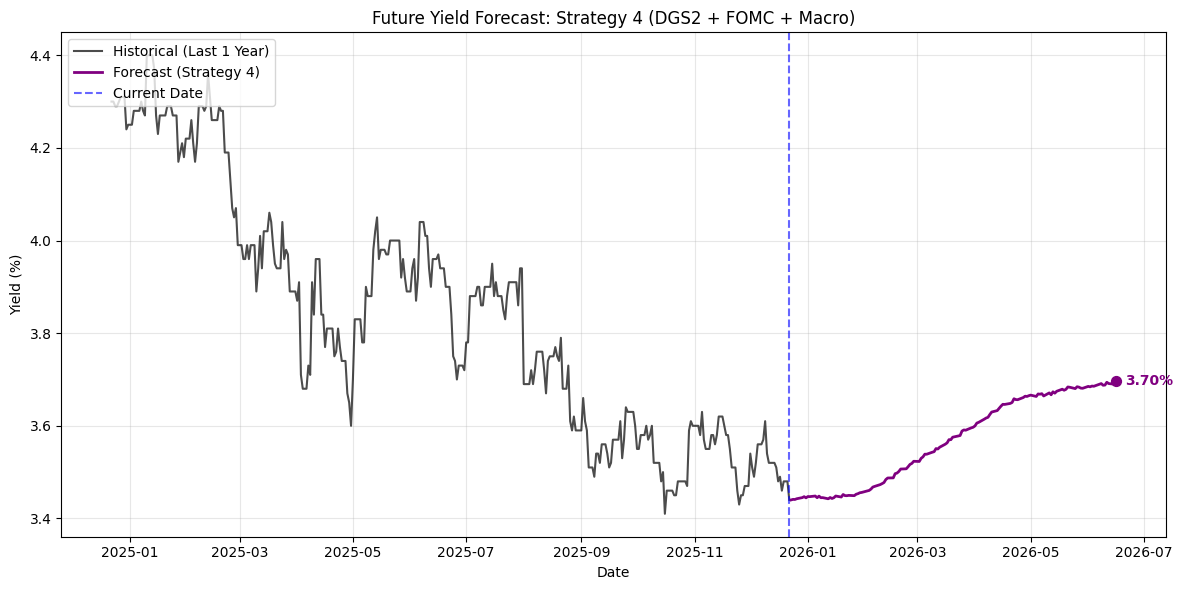

----------------------------------------
預測完成！
策略模式: all
預測區間: 2025-12-23 ~ 2026-06-16
預測 6 個月後的殖利率: 3.6961%
----------------------------------------


In [6]:
# ==========================================
# 執行策略 4 (All Combined) 未來 6 個月預測
# (維持原始設定，不強制調整相關係數門檻)
# ==========================================

# 1. 設定參數
STRATEGY_MODE = 'all'  # 指定策略 4: DGS2 + FOMC + Macro
FUTURE_MONTHS = 6
FUTURE_HORIZON = FUTURE_MONTHS * 21  # 約 126 個交易日
device = "cuda" if torch.cuda.is_available() else "cpu"

latest_date = data_pool.index[-1]
print(f">>> [最終預測] 啟動策略 4 (All Combined)")
print(f"    數據截止日: {latest_date.date()}")
print(f"    預測區間: 未來 {FUTURE_MONTHS} 個月")
print(f"    使用模式: {STRATEGY_MODE}")

# 2. 執行預測
# 直接呼叫函數，模型會根據 CORR_THRESHOLD (預設 0.7) 自動篩選特徵
future_values = predict_hybrid(
    data_pool, 
    FUTURE_HORIZON, 
    TARGET_COL, 
    EVENT_DATES_MAP, 
    CONTINUOUS_VARS, 
    device,
    mode=STRATEGY_MODE
)

# 3. 建立時間軸 (未來工作日)
future_dates = pd.bdate_range(start=latest_date + pd.Timedelta(days=1), periods=FUTURE_HORIZON)
df_forecast = pd.Series(future_values, index=future_dates, name='Forecast_Yield')

# 4. 視覺化結果
plt.figure(figsize=(12, 6))

# A. 繪製歷史數據 (最近 1 年)
plot_history_start = latest_date - pd.DateOffset(months=12)
history_segment = data_pool.loc[plot_history_start:, TARGET_COL]
plt.plot(history_segment.index, history_segment.values, label='Historical (Last 1 Year)', color='black', alpha=0.7)

# B. 繪製預測數據
plt.plot(df_forecast.index, df_forecast.values, label=f'Forecast (Strategy 4)', color='purple', linewidth=2)

# C. 標示與註解
plt.axvline(x=latest_date, color='blue', linestyle='--', alpha=0.6, label='Current Date')

# 標示最終點數值
final_val = df_forecast.iloc[-1]
plt.scatter([df_forecast.index[-1]], [final_val], color='purple', s=50, zorder=5)
plt.text(df_forecast.index[-1] + pd.Timedelta(days=5), final_val, f"{final_val:.2f}%", 
         fontsize=10, fontweight='bold', color='purple', va='center')

plt.title(f"Future Yield Forecast: Strategy 4 (DGS2 + FOMC + Macro)")
plt.xlabel("Date")
plt.ylabel("Yield (%)")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. 輸出文字結果
print("-" * 40)
print(f"預測完成！")
print(f"策略模式: {STRATEGY_MODE}")
print(f"預測區間: {future_dates[0].date()} ~ {future_dates[-1].date()}")
print(f"預測 6 個月後的殖利率: {final_val:.4f}%")
print("-" * 40)